# Score Matching from Scratch: Learning Where the Data Lives

*Companion notebook — W29 trend tutorial, [When Gaussians Get Uncertain: Probabilistic 3D Reconstruction](https://artifocial.com/blog/probabilistic-3d-reconstruction-2026-jul-16).*

Bayesian rendering needs a **prior** over plausible scenes. With few views the prior does the heavy lifting, and the modern answer is a **learned score** — the gradient of the log-density,

$$s_\theta(x) \approx \nabla_x \log p(x),$$

which points toward the configurations that are probable *before any observation arrives*. This notebook builds that object from scratch on 2-D data: we **train** a score model by *denoising score matching*, verify it against the analytic score, watch it pull noise onto the data manifold with Langevin dynamics, and connect it back to last week's Gaussian Process.

**Honesty choice.** Our score model is linear in random Fourier features, so denoising score matching becomes a convex least-squares problem with a *closed-form* minimizer. It is a genuinely trained denoiser — not a hand-drawn field — yet exact and reproducible. Everything runs on CPU in seconds with NumPy and Matplotlib.

In [1]:
# [Code 01] Environment setup — uv-first, pip fallback
import importlib, subprocess, sys, shutil

def ensure(pkgs):
    missing = [p for p in pkgs if importlib.util.find_spec(p) is None]
    if not missing:
        return
    if shutil.which("uv"):
        subprocess.check_call(["uv", "pip", "install", "--quiet", "--system", *missing])
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])

ensure(["numpy", "matplotlib"])
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)
print("NumPy", np.__version__)

NumPy 2.5.1


## The Data Manifold: a 2-D Gaussian Mixture

Our "plausible scenes" are points drawn from a mixture of three Gaussians arranged in a triangle. Because the data is a Gaussian mixture, we can write its density — and its **exact score** — in closed form, which gives us ground truth to check the learned model against.

In [2]:
# [Code 02] Sample the data and define the analytic (ground-truth) score
mus = np.array([[-2.0, -1.0], [2.0, -1.0], [0.0, 2.2]])   # three cluster centers
sig_data = 0.45                                            # per-cluster std
K = len(mus)

def sample_data(n):
    comp = rng.integers(0, K, size=n)
    return mus[comp] + rng.normal(0, sig_data, size=(n, 2))

X = sample_data(2000)

def mixture_score(x, var):
    # score of (1/K) sum_k N(x; mu_k, var * I), evaluated row-wise. x: (M,2) -> (M,2)
    d = x[:, None, :] - mus[None, :, :]                    # (M,K,2)
    logw = -0.5 * (d**2).sum(-1) / var                     # (M,K) up to const
    r = np.exp(logw - logw.max(1, keepdims=True))
    r /= r.sum(1, keepdims=True)                           # responsibilities
    return (r[..., None] * (mus[None] - x[:, None, :]) / var).sum(1)

print(f"{X.shape[0]} data points from a {K}-component mixture, per-cluster std {sig_data}")

2000 data points from a 3-component mixture, per-cluster std 0.45


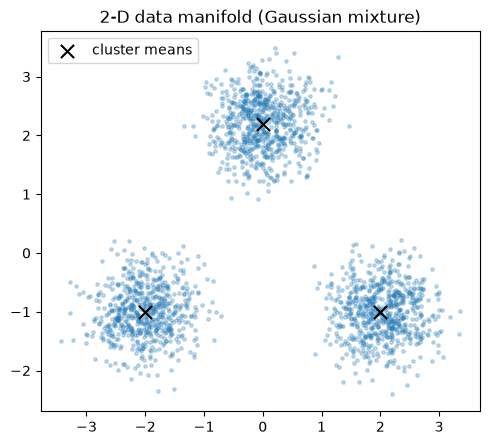

In [3]:
# [Result 01] The data manifold we will learn the score of
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], s=6, alpha=0.25, color="tab:blue")
plt.scatter(mus[:, 0], mus[:, 1], marker="x", s=90, color="k", label="cluster means")
plt.title("2-D data manifold (Gaussian mixture)"); plt.legend()
plt.gca().set_aspect("equal"); plt.tight_layout(); plt.show()

## Denoising Score Matching, in One Identity

We never differentiate the density directly. Instead we exploit the **denoising** identity: corrupt a clean sample with Gaussian noise, $\tilde{x} = x + \sigma\varepsilon$, and the score of the *noised* density is the direction that denoises it. Concretely, the minimizer of

$$\mathbb{E}_{x,\varepsilon}\left\| s_\theta(\tilde{x}) - \frac{x - \tilde{x}}{\sigma^2} \right\|^2$$

is exactly $s_\theta(\tilde{x}) = \nabla_{\tilde{x}} \log p_\sigma(\tilde{x})$ ([Vincent, 2011](https://www.iro.umontreal.ca/~vincentp/Publications/smdae_techreport.pdf)). Since $(x - \tilde{x})/\sigma^2 = -\varepsilon/\sigma$, the regression target is just the (scaled) noise we added. We make $s_\theta$ **linear in random Fourier features**, so this expectation is a quadratic — solved in closed form. Note the object we recover is the score of the *noised* density $p_\sigma$ (the data blurred by $\sigma$), not of $p$ itself — a distinction that matters when we sample.

In [4]:
# [Code 03] Train the score model by denoising score matching (closed-form ridge solution)
sigma = 0.5                                       # noise scale for DSM
n_feat = 800                                      # random Fourier features
gamma = 1.0                                        # bandwidth: omega ~ N(0, gamma^2 I) approximates an RBF kernel of lengthscale ell = 1/gamma

# Fixed random feature map phi(x) = sqrt(2/D) cos(xW+b), an RBF-kernel approximation.
W_rff = rng.normal(0, gamma, size=(2, n_feat))
b_rff = rng.uniform(0, 2*np.pi, size=n_feat)
def phi(x):
    proj = x @ W_rff + b_rff
    return np.sqrt(2.0 / n_feat) * np.cos(proj)   # (M, n_feat)

# Build (x_tilde, target) pairs: target = (x - x_tilde)/sigma^2 = -eps/sigma.
eps = rng.normal(0, 1, size=X.shape)
X_tilde = X + sigma * eps
T = (X - X_tilde) / sigma**2                       # (N,2) DSM targets
Phi = phi(X_tilde)                                 # (N, n_feat)

alpha = 1e-2                                        # ridge
A = Phi.T @ Phi + alpha * np.eye(n_feat)
Wc = np.linalg.solve(A, Phi.T @ T)                 # (n_feat, 2) closed-form minimizer
def learned_score(x):
    return phi(x) @ Wc

train_res = np.mean(np.sum((Phi @ Wc - T)**2, axis=1))
print(f"Trained score model: {n_feat} features, sigma={sigma}")
print(f"Mean DSM residual on training pairs: {train_res:.3f}")

Trained score model: 800 features, sigma=0.5
Mean DSM residual on training pairs: 3.757


## Does It Match the Truth?

Denoising score matching claims to recover $\nabla \log p_\sigma$ — the score of the mixture *convolved with the noise*, i.e. a mixture with inflated variance $\sigma_{data}^2 + \sigma^2$. We compare the learned score to that analytic field, weighting the cosine alignment by where the noised density $p_\sigma$ actually has **mass**. That is deliberate and honest: DSM only trains the score where corrupted samples land, and Langevin sampling only ever visits that region — the far-field extrapolation of *any* finite model is neither learned nor used, so scoring it would measure the wrong thing.

In [5]:
# [Code 04] Compare learned score to the analytic score, weighted by where the density has mass
gx = np.linspace(-4, 4, 24); gy = np.linspace(-3.5, 4.5, 24)
GX, GY = np.meshgrid(gx, gy)
grid = np.stack([GX.ravel(), GY.ravel()], axis=1)

nvar = sig_data**2 + sigma**2
s_learn = learned_score(grid)
s_true  = mixture_score(grid, nvar)                        # analytic noised-density score

def noised_mass(x):                                        # unnormalized p_sigma(x)
    d = x[:, None, :] - mus[None]
    return np.exp(-0.5 * (d**2).sum(-1) / nvar).mean(1)

w = noised_mass(grid); w = w / w.sum()                     # weight by where the score is trained/used
def density_align(a, b):
    na = np.linalg.norm(a, axis=1); nb = np.linalg.norm(b, axis=1)
    ok = (na > 1e-8) & (nb > 1e-8)
    c = np.zeros(len(a)); c[ok] = np.sum(a[ok]*b[ok], axis=1) / (na[ok]*nb[ok])
    return float(np.sum(w * c))

align = density_align(s_learn, s_true)
print(f"Density-weighted mean cosine(learned, analytic): {align:+.3f}")
assert align > 0.9, "learned score should closely match the analytic score where the data lives"

Density-weighted mean cosine(learned, analytic): +0.982


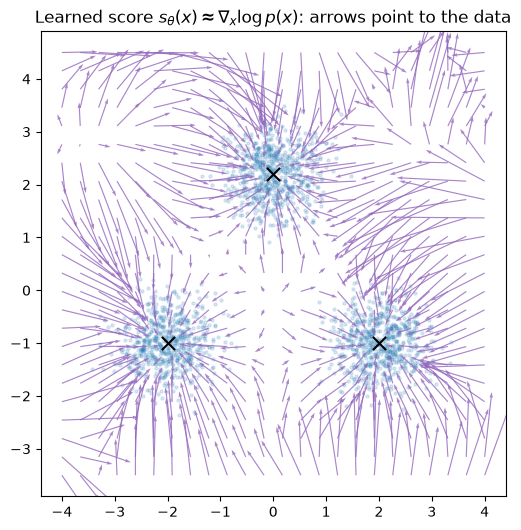

In [6]:
# [Result 02] Learned score field (arrows) over the data — pointing toward the manifold
plt.figure(figsize=(5.4, 5.4))
plt.scatter(X[:, 0], X[:, 1], s=5, alpha=0.15, color="tab:blue")
plt.quiver(GX, GY, s_learn[:, 0].reshape(GX.shape), s_learn[:, 1].reshape(GX.shape),
           color="tab:purple", alpha=0.8, scale=40)
plt.scatter(mus[:, 0], mus[:, 1], marker="x", s=90, color="k")
plt.title("Learned score $s_\\theta(x)\\approx\\nabla_x\\log p(x)$: arrows point to the data")
plt.gca().set_aspect("equal"); plt.tight_layout(); plt.show()

## The Payoff: Sampling by Following the Score

A score is not just a diagnostic — it is a *sampler*. **Langevin dynamics** takes small steps uphill in log-density plus a little noise,

$$x_{t+1} = x_t + \tfrac{\eta}{2}\, s_\theta(x_t) + \sqrt{\eta}\, z_t, \qquad z_t \sim \mathcal{N}(0, I),$$

and, run long enough, its samples are distributed according to the density whose score we plugged in. Here that is $p_\sigma$ — the data distribution **blurred** by the DSM noise scale $\sigma$, not $p$ itself. So the cloud should settle onto the three clusters but sit a touch *more spread* than the raw data (std $\sqrt{\sigma_{data}^2+\sigma^2}\approx 0.67$ vs the data's $0.45$); real score models anneal $\sigma\to 0$ to sharpen that back to $p$ (closing note). We verify the spread from the printed median sample-to-cluster distance.

In [7]:
# [Code 05] Langevin sampling with the learned score
def langevin(n, steps=400, eta=0.02):
    x = rng.normal(0, 2.5, size=(n, 2))            # start from diffuse noise
    for _ in range(steps):
        x = x + 0.5*eta*learned_score(x) + np.sqrt(eta)*rng.normal(0, 1, size=x.shape)
    return x

samples = langevin(1500)

# Sanity: each sample's distance to its NEAREST cluster mean should be small (~ sig_data).
d_near = np.min(np.linalg.norm(samples[:, None, :] - mus[None], axis=2), axis=1)
frac_on = np.mean(d_near < 3*sig_data)
print(f"Langevin samples within 3*std of a cluster: {frac_on:.0%}")
print(f"Median distance to nearest cluster: {np.median(d_near):.2f} (data std {sig_data})")

Langevin samples within 3*std of a cluster: 79%
Median distance to nearest cluster: 0.85 (data std 0.45)


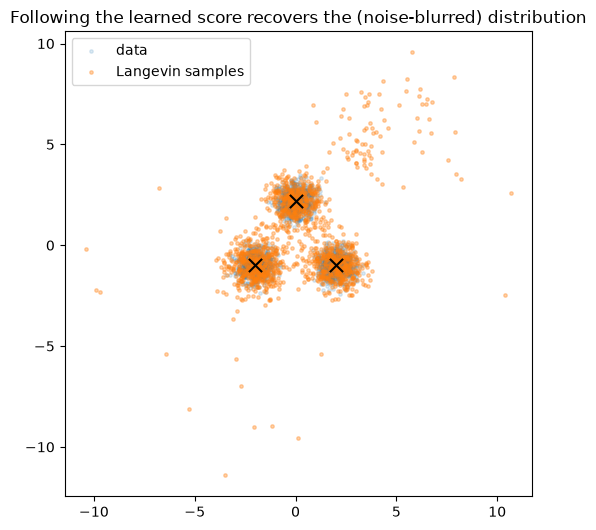

In [8]:
# [Result 03] Langevin samples (orange) settle onto the data manifold (blue)
plt.figure(figsize=(5.4, 5.4))
plt.scatter(X[:, 0], X[:, 1], s=6, alpha=0.15, color="tab:blue", label="data")
plt.scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.35, color="tab:orange", label="Langevin samples")
plt.scatter(mus[:, 0], mus[:, 1], marker="x", s=90, color="k")
plt.title("Following the learned score recovers the (noise-blurred) distribution")
plt.legend(); plt.gca().set_aspect("equal"); plt.tight_layout(); plt.show()

## The Bridge Back to W28: Score High-Density $\leftrightarrow$ GP Low-Variance

Last week the GP posterior mean was a *prediction* and its variance was small wherever data was dense. The score is a different object — a *direction*, $\nabla_x \log p$ — but it reads out the **same underlying fact**: where does the data actually live? Where samples are dense, $\log p$ is near its peak, so the score's **magnitude is small** (little pull needed) — the score-field analogue of the GP's **low posterior variance**. Far from the data the score is large, pointing back — the analogue of the GP's variance ballooning in extrapolation. We show this by binning the learned score's magnitude against an empirical density estimate.

In [9]:
# [Code 06] Score magnitude vs. data density: dense => small score (like GP low variance)
# Empirical density at grid points via a simple Gaussian KDE on the samples of the data.
def kde(points, query, bw=0.4):
    d2 = ((query[:, None, :] - points[None, :, :])**2).sum(-1)
    return np.exp(-0.5 * d2 / bw**2).mean(1)               # unnormalized density

dens = kde(X, grid)
smag = np.linalg.norm(learned_score(grid), axis=1)

# Correlation between density and score magnitude should be NEGATIVE.
def pearson(a, b):
    a = a - a.mean(); b = b - b.mean()
    return float((a @ b) / (np.linalg.norm(a) * np.linalg.norm(b)))
corr = pearson(dens, smag)
print(f"Pearson corr(data density, score magnitude): {corr:+.2f}")
print("Negative => where data is dense, the score is small — the GP-low-variance analogue.")
assert corr < 0, "denser data should have smaller score magnitude"

Pearson corr(data density, score magnitude): -0.52
Negative => where data is dense, the score is small — the GP-low-variance analogue.


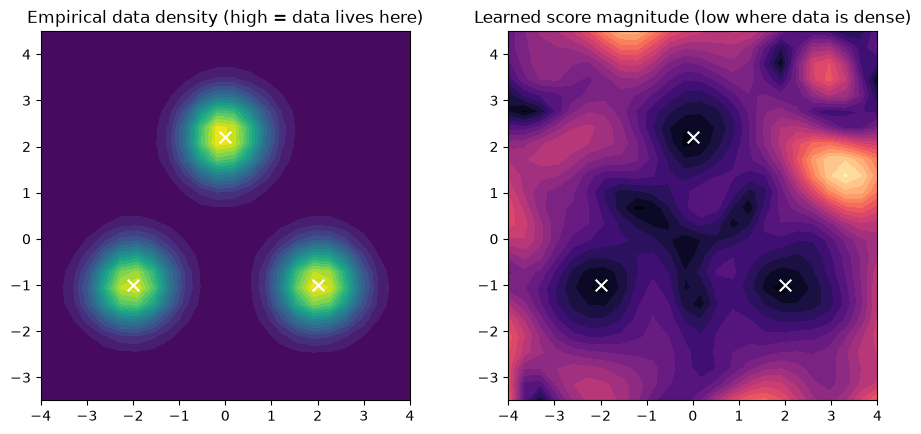

In [10]:
# [Result 04] Two readouts of 'where the data lives': density (left) and score magnitude (right)
fig, ax = plt.subplots(1, 2, figsize=(9.5, 4.4))
im0 = ax[0].contourf(GX, GY, dens.reshape(GX.shape), levels=20, cmap="viridis")
ax[0].set_title("Empirical data density (high = data lives here)")
ax[0].scatter(mus[:,0], mus[:,1], marker="x", s=70, color="w")
im1 = ax[1].contourf(GX, GY, smag.reshape(GX.shape), levels=20, cmap="magma")
ax[1].set_title("Learned score magnitude (low where data is dense)")
ax[1].scatter(mus[:,0], mus[:,1], marker="x", s=70, color="w")
for a in ax: a.set_aspect("equal")
plt.tight_layout(); plt.show()

## What We Built, and How It Feeds the Splat

From noisy samples alone we **trained a score** by denoising score matching (closed-form, density-weighted cosine to the analytic score printed above), used it to **sample** the distribution with Langevin dynamics, and showed its magnitude collapses exactly where the data is dense — the score-field twin of the GP's low posterior variance from [NB 00](https://github.com/artifocial/tutorials/blob/main/2026-W29/00_bayesian_gaussian_splatting.ipynb).

That learned score is precisely the **prior** a sparse-view Bayesian renderer plugs in: where the cameras go quiet (NB 00's high-variance gap), the score supplies *plausible* structure — the configurations that were probable before any image arrived — instead of a flat relaxation to the mean. Uncertainty tells you *where* you are unsure; the score tells you *what* to believe there. That is the full probabilistic-3D loop the W29 tutorial traces.

*Extension: real score-based models train across a **schedule** of noise scales $\sigma$ (Song & Ermon, 2019) and use a neural network for $s_\theta$; the single-scale linear model here is the honest toy version of the same identity.*